

```
# This is formatted as code
```

**Module 2: Foundations + Critical Lens on the Data Science Life Cycle** The provided code notebook presents an example of linear regression models with similar accuracies but distinct FPR/FNR.<br>
We provide the code to:
1) Generate two sets of synthetic data (predictor/input feature and outcome 0/1).
2) Train a linear regression model for each dataset.
3) Compute multiple evaluation metrics (accuracy, FPR, FNR).
4) Visualize the differences in FPR and FNR between the two models.

The codebook uses linear regression training as a simple teaching tool, not as a recommended model for binary prediction.

The purpose of the code notebook is to provide students with a hands-on example of a human-centered data science problem and potential biases.

This code notebook is used to help students:<br>
* Locate human touchpoints.<br>
* Explain abstraction traps.<br>
* Discuss harm beyond accuracy.<br>

The code can be adapted as instructors see fit, including lengthening the example, creating more/different features, and/or using your own dataset.

In [31]:
# Requirements: numpy, pandas, matplotlib, seaborn, scikit-learn
# Tested with Python 3.12, scikit-learn >= 1.0

#import needed packages
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

np.random.seed(42)

# create custom HCDS palette
custom_palette = ['#1c5b49', '#a4dfce', '#15ad81', '#71cdb3', '#178868', '#adadad']

In [32]:
#generating synthetic data
def generate_data(n=300, bias=0.0, noise=1.0):
    X = np.random.randn(n, 1)
    y_continuous = X.squeeze() + bias + noise * np.random.randn(n)
    y = (y_continuous > 0).astype(int)
    return X, y

 **Prompt:** "For the dataset created here, imagine X represents a risk score used to decide whether to investigate a case. Label outcome = 1 means ‘investigate’."

 **Ask:** "If a 1 means investigate, who is harmed by a false positive?"

 **Ask:** "Who is harmed by a false negative?"


In [33]:
#dataset A
XA, yA = generate_data(bias=-0.3, noise=1.2)

#dataset B
XB, yB = generate_data(bias=0.3, noise=1.2)

print(XA[:10], yA[:10])

[[ 0.49671415]
 [-0.1382643 ]
 [ 0.64768854]
 [ 1.52302986]
 [-0.23415337]
 [-0.23413696]
 [ 1.57921282]
 [ 0.76743473]
 [-0.46947439]
 [ 0.54256004]] [0 0 1 1 0 0 1 0 0 0]


**Ask:** How many columns would *you* use in a linear regression task? Is one predictive column enough? Why or why not?

**Ask:** What information can a single variable fail to represent and what forms of human context are being abstracted away?

In [34]:
#training linear regression models to predict y from X

#use train/test split
def train_and_evaluate(X, y, threshold=0.5):
    X_train, X_test, y_train, y_test = train_test_split(
      X, y,
      test_size=0.2,
      random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_cont = model.predict(X_test)
    y_pred = (y_pred_cont >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    return model, acc, fpr, fnr, X_test, y_test, y_pred_cont

In [35]:
#train both linear regression models, using X to predict y
modelA, accA, fprA, fnrA, XA_test, yA_test, predsA = train_and_evaluate(XA, yA)
modelB, accB, fprB, fnrB, XB_test, yB_test, predsB = train_and_evaluate(XB, yB)

 **Prompt:** "We can use a multitude of evaluation metrics for data science models such as this."

 **Ask:** "Which evaluation metrics are more meaningful in different scenarios?"

 **Ask:** "Which stakeholders are harmed by high false positive rates versus high false negative rates? How that should affect threshold choice?"

In [36]:
#print evaluation metrics
print("Dataset A")
print(f"Accuracy: {accA:.3f}, FPR: {fprA:.3f}, FNR: {fnrA:.3f}\n")

print("Dataset B")
print(f"Accuracy: {accB:.3f}, FPR: {fprB:.3f}, FNR: {fnrB:.3f}")

Dataset A
Accuracy: 0.667, FPR: 0.326, FNR: 0.353

Dataset B
Accuracy: 0.733, FPR: 0.462, FNR: 0.118


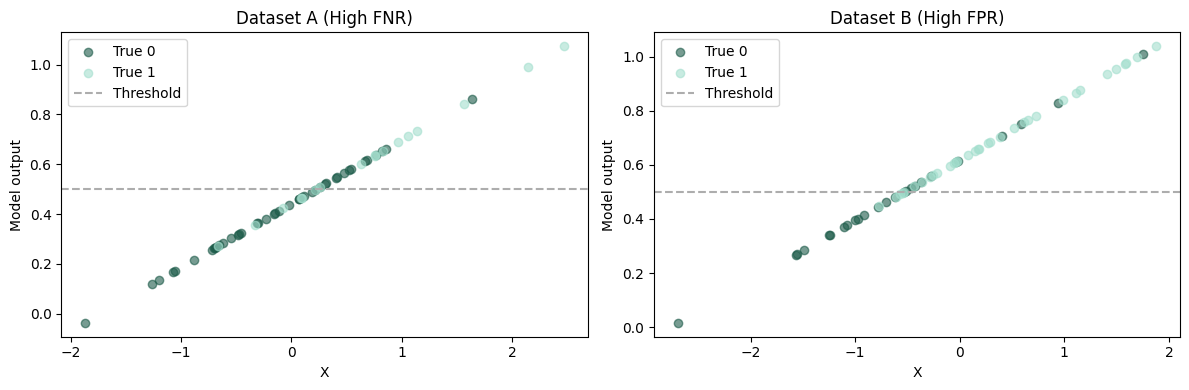

In [37]:
#visualization of results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, X, y, preds, title in [
    (axes[0], XA_test, yA_test, predsA, "Dataset A (High FNR)"),
    (axes[1], XB_test, yB_test, predsB, "Dataset B (High FPR)")
]:
    ax.scatter(X[y == 0], preds[y == 0], label="True 0", alpha=0.6, color=custom_palette[0])
    ax.scatter(X[y == 1], preds[y == 1], label="True 1", alpha=0.6, color=custom_palette[1])
    ax.axhline(0.5, color=custom_palette[5], linestyle="--", label="Threshold")
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Model output")
    ax.legend()

plt.tight_layout()
plt.show()


**Ask:** "What do you notice about the axes of these figures, how do they differ?"

**Ask:** "What is the threshold determining? How does the same threshold affects the two datasets differently?"

**Ask:** "How does overall accuracy hide meaningful differences in error?"

**Explore Further:**

1. Change the synthetic data values and rerun the model.
* How do overall accuracy and FP/FN rates change?
* Are some subgroups more affected than others by the data distribution changes?

2. Retrain the linear regression on a different dataset with more columns. Does that reduce or increase disparities in errors? Does it change overall accuracy?
* Does adding features reduce or increase disparities in prediction errors across subgroups?
* How does overall accuracy change?
* Do additional features introduce new sources of bias?

3. How does the institutional context change the risk of high FP/FN rates? Consider healthcare vs criminal justice, do these contexts change how you think about the model?

**Connecting back to Human Centered Data Science:**

This activity emphasizes the importance of human-in-the-loop methods at each stage of the data science life cycle (from data collection to modeling to evaluation).

**Misleading metrics:** Two models can have nearly identical accuracy while behaving very differently in practice.

**Data construction/collection:** Model behavior is often driven by the data, not by the algorithm built.

**Evaluation trade-offs:** You usually can’t minimize FPR and FNR simultaneously.

**Abstraction Traps:** The model reduces a socially situated decision to a single numeric predictor and binary label, this simplification shapes what harms become visible or invisible.

**"Best" performance:** There is no universally “best” model — only models that are better for specific goals and constraints.

**Action:** What changes could you make to this example to reduce the disparity in FPR/FNR?